In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/shampoo.csv"

df = pd.read_csv(url)

df.columns = ["Month", "Sales"]

df.head()

,Month,Sales
0,1-01,266.0
1,1-02,145.9
2,1-03,183.1
3,1-04,119.3
4,1-05,180.3


In [3]:
df.info()

df.isnull().sum()

df.drop_duplicates(inplace=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Month   36 non-null     object 
 1   Sales   36 non-null     float64
dtypes: float64(1), object(1)
memory usage: 708.0+ bytes


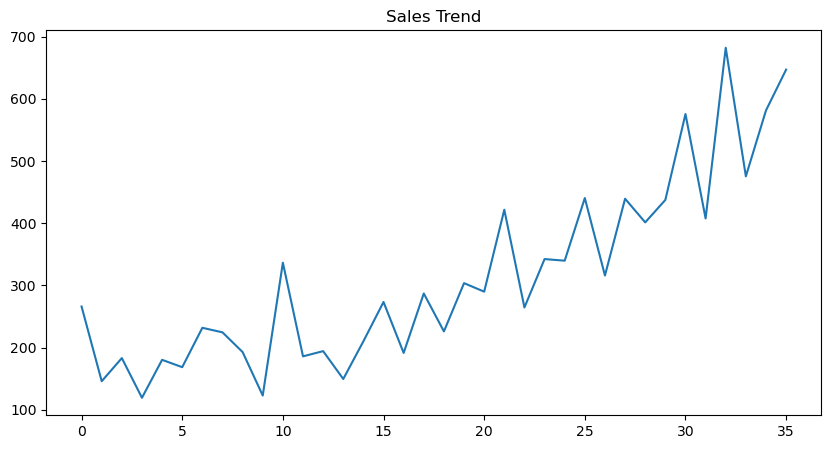

In [4]:
plt.figure(figsize=(10,5))

plt.plot(df["Sales"])

plt.title("Sales Trend")

plt.show()

In [5]:
df["Time"] = np.arange(len(df))
df.head()

,Month,Sales,Time
0,1-01,266.0,0
1,1-02,145.9,1
2,1-03,183.1,2
3,1-04,119.3,3
4,1-05,180.3,4


In [6]:
train = df[:-6]
test = df[-6:]

X_train = train[["Time"]]
y_train = train["Sales"]

X_test = test[["Time"]]
y_test = test["Sales"]

In [7]:
lr = LinearRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

In [8]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [9]:
print("Linear Regression MAE:", mean_absolute_error(y_test, pred_lr))
print("Random Forest MAE:", mean_absolute_error(y_test, pred_rf))

print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_test, pred_lr)))
print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, pred_rf)))

Linear Regression MAE: 140.6845383759734
Random Forest MAE: 142.07466666666616
Linear Regression RMSE: 167.1957855998035
Random Forest RMSE: 165.73678241114672


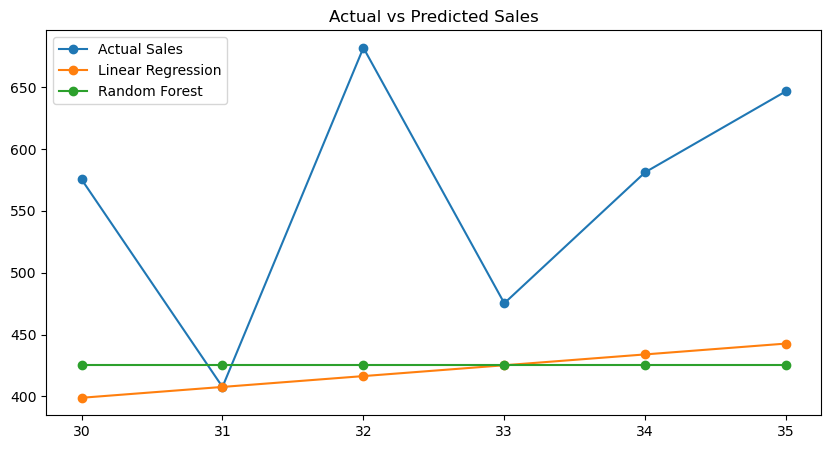

In [10]:
plt.figure(figsize=(10,5))

plt.plot(test.index, y_test, label="Actual Sales", marker='o')
plt.plot(test.index, pred_lr, label="Linear Regression", marker='o')
plt.plot(test.index, pred_rf, label="Random Forest", marker='o')

plt.legend()
plt.title("Actual vs Predicted Sales")
plt.show()

In [11]:
future_time = np.arange(len(df), len(df)+6).reshape(-1,1)

future_sales = lr.predict(future_time)

print("Future Sales Forecast:")
for i, val in enumerate(future_sales, 1):
    print(f"Month {i}: {val:.2f}")

Future Sales Forecast:
Month 1: 451.45
Month 2: 460.23
Month 3: 469.00
Month 4: 477.77
Month 5: 486.55
Month 6: 495.32


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


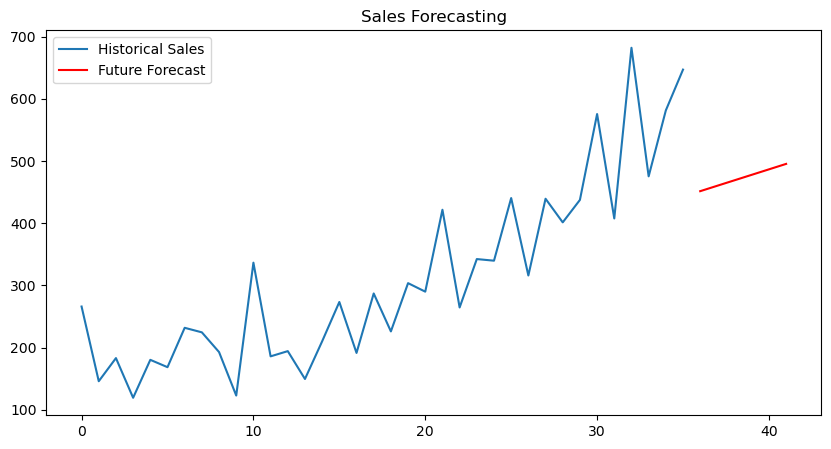

In [12]:
plt.figure(figsize=(10,5))

plt.plot(df["Time"], df["Sales"], label="Historical Sales")
plt.plot(future_time, future_sales, color="red", label="Future Forecast")

plt.legend()
plt.title("Sales Forecasting")
plt.show()